In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from causalimpact import CausalImpact

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:
df = pd.read_csv('online_retail_II.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['Revenue'] = df['Quantity'] * df['Price']

daily = df.groupby(df['InvoiceDate'].dt.date)['Revenue'].sum().reset_index()
daily.columns = ['Date', 'Revenue']
daily['Date'] = pd.to_datetime(daily['Date'])
daily = daily.sort_values('Date').reset_index(drop=True)

print(f"기간: {daily['Date'].min().date()} ~ {daily['Date'].max().date()}")
print(f"총 {len(daily)}일치 데이터")

기간: 2009-12-01 ~ 2011-12-09
총 604일치 데이터


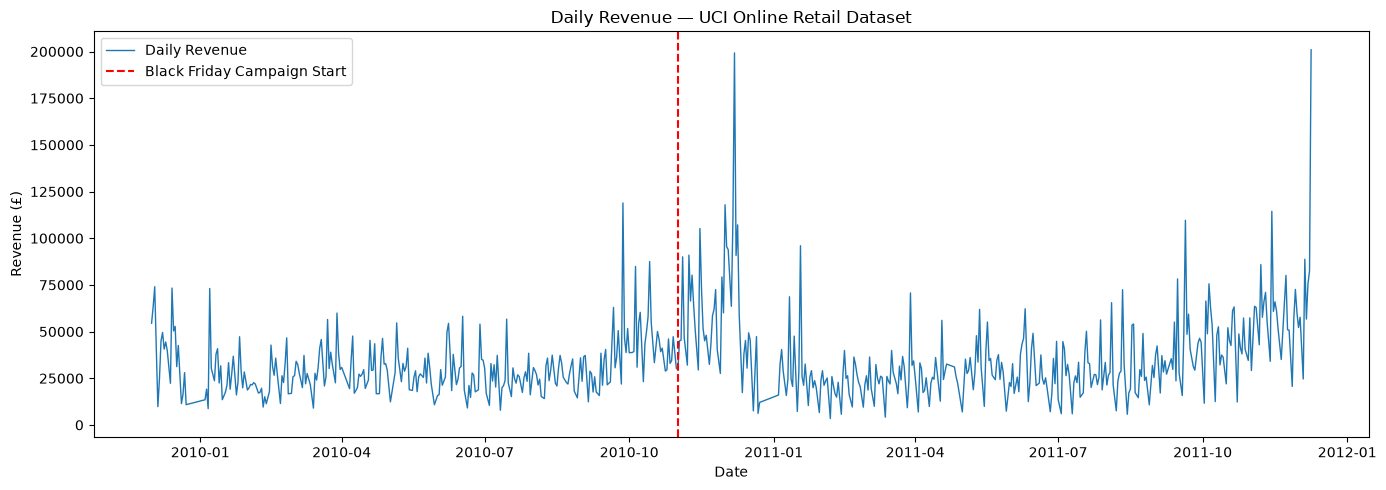

캠페인 전 일평균: £30,757
캠페인 후 일평균: £37,993
단순 전후 비교: +23.5%
→ 단순 비교만으로는 이게 캠페인 효과인지 계절성인지 알 수 없음


In [3]:
campaign_start = pd.Timestamp('2010-11-01')

plt.figure(figsize=(14, 5))
plt.plot(daily['Date'], daily['Revenue'], linewidth=1, label='Daily Revenue')
plt.axvline(x=campaign_start, color='red', linestyle='--', linewidth=1.5, label='Black Friday Campaign Start')
plt.title('Daily Revenue — UCI Online Retail Dataset')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.tight_layout()
plt.savefig('fig_01_daily_revenue.png', dpi=150)
plt.show()

pre = daily[daily['Date'] < campaign_start]['Revenue'].mean()
post = daily[daily['Date'] >= campaign_start]['Revenue'].mean()
print(f"캠페인 전 일평균: £{pre:,.0f}")
print(f"캠페인 후 일평균: £{post:,.0f}")
print(f"단순 전후 비교: {((post-pre)/pre*100):+.1f}%")
print("→ 단순 비교만으로는 이게 캠페인 효과인지 계절성인지 알 수 없음")

C:\api\k\online_retail_test\causal_env\Lib\site-packages\causalimpact\misc.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_mu = data_mu[0]
C:\api\k\online_retail_test\causal_env\Lib\site-packages\causalimpact\misc.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_sd = data_sd[0]
C:\api\k\online_retail_test\causal_env\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


                                Average           Cumulative
Actual                            37993             12575827
Predicted                         36887             12209750
95% CI                   [14097, 59676]  [4666418, 19753083]
                                                            
Absolute Effect                    1105               366077
95% CI                  [23895, -21683]  [7909409, -7177255]
                                                            
Relative Effect                    3.0%                 3.0%
95% CI                  [64.8%, -58.8%]      [64.8%, -58.8%]
                                                            
P-value                            0.1%                     
Prob. of Causal Effect            99.9%                     
None


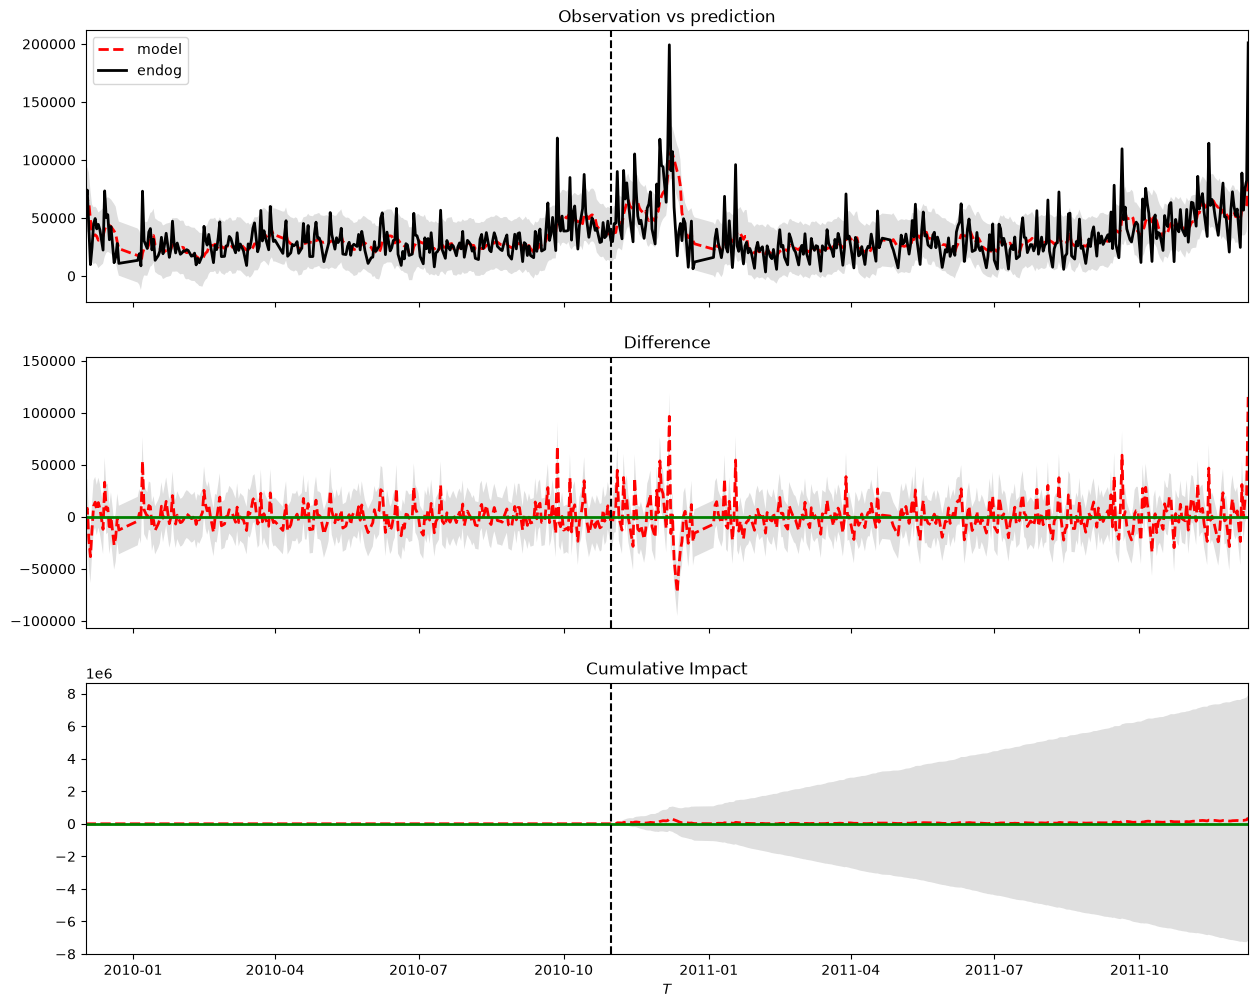

<Figure size 640x480 with 0 Axes>

In [4]:
ci_data = daily.set_index('Date')[['Revenue']].copy()
ci_data['Revenue_MA7'] = ci_data['Revenue'].rolling(7, min_periods=1).mean()

pre_period = ['2009-12-01', '2010-10-31']
post_period = ['2010-11-01', '2011-12-09']

ci = CausalImpact(ci_data, pre_period, post_period)
ci.run()
print(ci.summary())
ci.plot()
plt.savefig('fig_02_causal_impact.png', dpi=150)
plt.show()

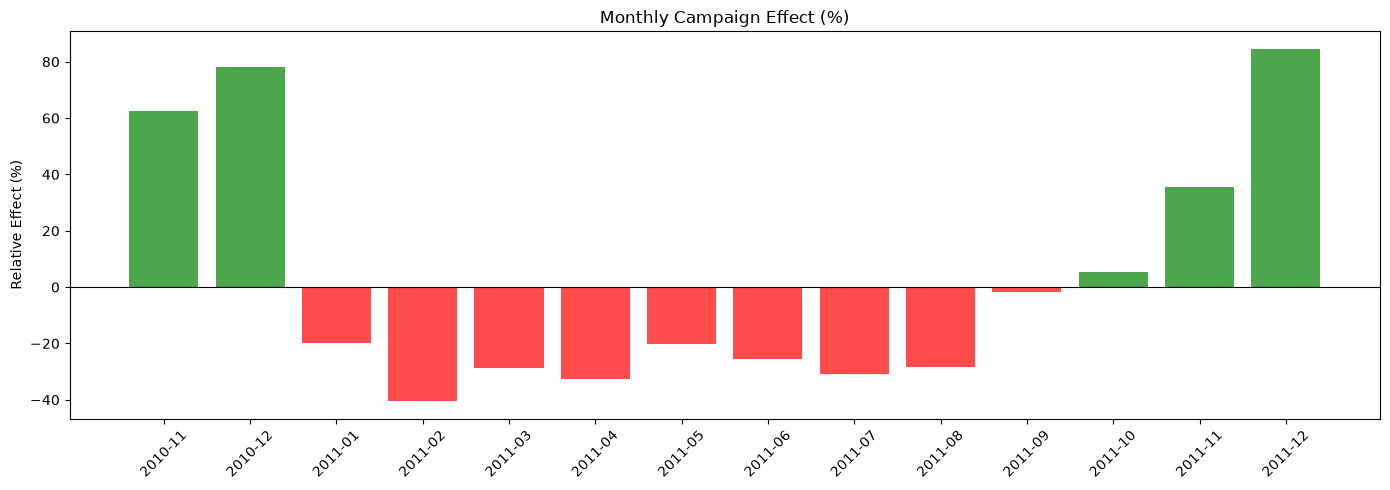

In [5]:
post_df = daily[daily['Date'] >= campaign_start].copy()
pre_df = daily[daily['Date'] < campaign_start].copy()

pre_df['t'] = np.arange(len(pre_df))
coeffs = np.polyfit(pre_df['t'], pre_df['Revenue'], 1)

post_df = post_df.copy()
post_df['t'] = np.arange(len(pre_df), len(pre_df) + len(post_df))
post_df['Predicted'] = np.polyval(coeffs, post_df['t'])
post_df['Effect'] = post_df['Revenue'] - post_df['Predicted']

post_df['Month'] = post_df['Date'].dt.to_period('M')
monthly = post_df.groupby('Month').agg(
    Actual=('Revenue', 'sum'),
    Predicted=('Predicted', 'sum'),
    Effect=('Effect', 'sum')
).reset_index()
monthly['Relative_Effect'] = monthly['Effect'] / monthly['Predicted'] * 100
monthly['Month_str'] = monthly['Month'].astype(str)

colors = ['green' if x > 0 else 'red' for x in monthly['Relative_Effect']]
plt.figure(figsize=(14, 5))
plt.bar(monthly['Month_str'], monthly['Relative_Effect'], color=colors, alpha=0.7)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Monthly Campaign Effect (%)')
plt.ylabel('Relative Effect (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig_03_monthly_effect.png', dpi=150)
plt.show()